In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

In [5]:
#Simular data
np.random.seed(42)
n_players = 100000
data = pd.DataFrame({
    'Experiencia': np.random.choice(['Bajo', 'Medio', 'Alto'], size=n_players, p=[0.30, 0.50, 0.20]),
    'Equipamiento': np.random.choice(['Básico', 'Intermedio', 'Avanzado'], size=n_players, p=[0.40, 0.40, 0.20]),
    'Estado_mental': np.random.choice(['Positivo', 'Neutral', 'Negativo'], size=n_players, p=[0.45, 0.40, 0.15]),
    'Exito_mision': np.random.choice(['Sí', 'No'], size=n_players, p=[0.50, 0.50])
                                      })

In [6]:
# Alto + Avanzado
data.loc[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Positivo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.95,0.05], size=len(data[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Positivo')]))
data.loc[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Neutral'),  'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.90,0.10], size=len(data[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Neutral')]))
data.loc[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Negativo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.75,0.25], size=len(data[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Negativo')]))

# Alto + Intermedio
data.loc[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Positivo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.85,0.15], size=len(data[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Positivo')]))
data.loc[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Neutral'),  'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.75,0.25], size=len(data[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Neutral')]))
data.loc[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Negativo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.60,0.40], size=len(data[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Negativo')]))

# Alto + Básico
data.loc[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Positivo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.70,0.30], size=len(data[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Positivo')]))
data.loc[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Neutral'),  'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.60,0.40], size=len(data[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Neutral')]))
data.loc[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Negativo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.45,0.55], size=len(data[(data['Experiencia']=='Alto') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Negativo')]))

# Medio + Avanzado
data.loc[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Positivo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.80,0.20], size=len(data[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Positivo')]))
data.loc[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Neutral'),  'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.70,0.30], size=len(data[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Neutral')]))
data.loc[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Negativo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.55,0.45], size=len(data[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Negativo')]))

# Medio + Intermedio
data.loc[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Positivo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.70,0.30], size=len(data[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Positivo')]))
data.loc[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Neutral'),  'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.55,0.45], size=len(data[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Neutral')]))
data.loc[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Negativo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.40,0.60], size=len(data[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Negativo')]))

# Medio + Básico
data.loc[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Positivo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.55,0.45], size=len(data[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Positivo')]))
data.loc[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Neutral'),  'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.45,0.55], size=len(data[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Neutral')]))
data.loc[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Negativo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.30,0.70], size=len(data[(data['Experiencia']=='Medio') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Negativo')]))

# Bajo + Avanzado
data.loc[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Positivo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.60,0.40], size=len(data[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Positivo')]))
data.loc[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Neutral'),  'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.50,0.50], size=len(data[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Neutral')]))
data.loc[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Negativo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.35,0.65], size=len(data[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Avanzado') & (data['Estado_mental']=='Negativo')]))

# Bajo + Intermedio
data.loc[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Positivo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.50,0.50], size=len(data[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Positivo')]))
data.loc[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Neutral'),  'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.40,0.60], size=len(data[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Neutral')]))
data.loc[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Negativo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.25,0.75], size=len(data[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Intermedio') & (data['Estado_mental']=='Negativo')]))

# Bajo + Básico
data.loc[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Positivo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.40,0.60], size=len(data[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Positivo')]))
data.loc[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Neutral'),  'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.30,0.70], size=len(data[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Neutral')]))
data.loc[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Negativo'), 'Exito_mision'] = np.random.choice(['Sí','No'], p=[0.15,0.85], size=len(data[(data['Experiencia']=='Bajo') & (data['Equipamiento']=='Básico') & (data['Estado_mental']=='Negativo')]))




In [8]:
#Encode categorical variables
encoder = OrdinalEncoder()
X = encoder.fit_transform(data[['Experiencia', 'Equipamiento', 'Estado_mental']])
y = data['Exito_mision'].map({'No': 0, 'Sí':1})

In [9]:
#Entrenar el modelo de Naive Bayes
# Train Naive Bayes model
model = CategoricalNB()
model.fit(X, y)

# Predict probabilities for each combination
combinations = pd.DataFrame({
    'Experiencia': ['Alto', 'Alto', 'Alto', 'Alto', 'Alto', 'Alto', 'Alto', 'Alto', 'Alto', 
                    'Medio', 'Medio', 'Medio', 'Medio', 'Medio', 'Medio', 'Medio', 'Medio', 'Medio', 
                    'Bajo', 'Bajo', 'Bajo', 'Bajo', 'Bajo', 'Bajo', 'Bajo', 'Bajo', 'Bajo'],
    'Equipamiento': ['Avanzado', 'Avanzado', 'Avanzado', 'Intermedio', 'Intermedio', 'Intermedio', 'Básico', 'Básico', 'Básico',
                    'Avanzado', 'Avanzado', 'Avanzado', 'Intermedio', 'Intermedio', 'Intermedio', 'Básico', 'Básico', 'Básico',
                    'Avanzado', 'Avanzado', 'Avanzado', 'Intermedio', 'Intermedio', 'Intermedio', 'Básico', 'Básico', 'Básico'],
    'Estado_mental': ['Positivo', 'Neutral', 'Negativo', 'Positivo', 'Neutral', 'Negativo', 'Positivo', 'Neutral', 'Negativo',
                      'Positivo', 'Neutral', 'Negativo', 'Positivo', 'Neutral', 'Negativo', 'Positivo', 'Neutral', 'Negativo',
                      'Positivo', 'Neutral', 'Negativo', 'Positivo', 'Neutral', 'Negativo', 'Positivo', 'Neutral', 'Negativo']
})
X_new = encoder.transform(combinations)
probs = model.predict_proba(X_new)

In [10]:
# Add probabilities to the combinations DataFrame
combinations['P(Exito_mision = No)'] = probs[:, 0]
combinations['P(Exito_mision = Sí)'] = probs[:, 1]

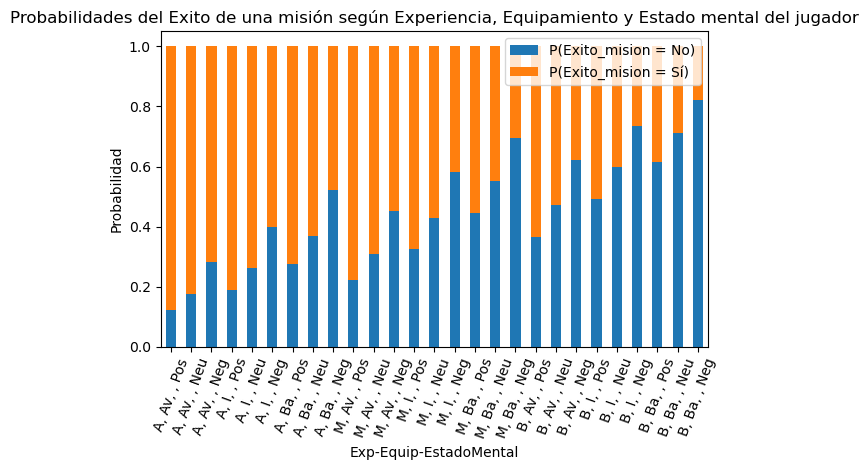

In [23]:

abbr = {
    'Bajo':'B', 'Medio':'M', 'Alto':'A',
    'Básico':'Ba', 'Intermedio':'I', 'Avanzado':'Av',
    'Positivo':'Pos', 'Neutral':'Neu', 'Negativo':'Neg'
}

# Cominar Experiencia, Equipamiento y estado_mental en un solo eje x
combinations['Etiqueta'] = combinations.apply(lambda row: f"{abbr[row['Experiencia']]}, {abbr[row['Equipamiento']]}, , {abbr[row['Estado_mental']]}", axis=1)

# Plot the probabilities
combinations.plot(x='Etiqueta', y=['P(Exito_mision = No)', 'P(Exito_mision = Sí)'], kind='bar', stacked=True)
plt.title('Probabilidades del Exito de una misión según Experiencia, Equipamiento y Estado mental del jugador')
plt.xlabel('Exp-Equip-EstadoMental')
plt.ylabel('Probabilidad')
plt.xticks(rotation=70)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the plot
plt.savefig('probabilidades_condicionales_exito_mision_naive_bayes.png')

Text(0.5, 0.98, 'Probabilidad de Éxito de misión')

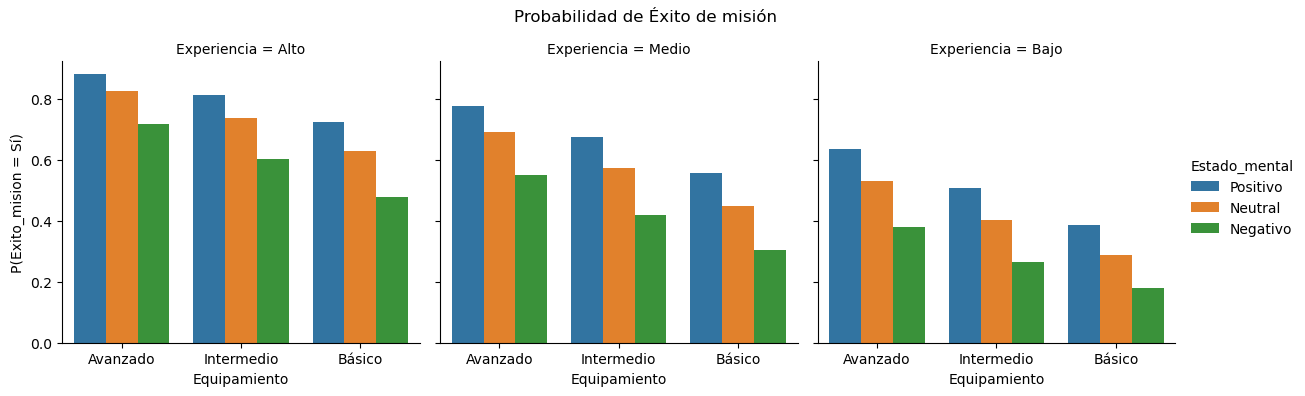

In [29]:
#Separar en gráficas para que sea más claro
import seaborn as sns

g = sns.catplot(
    data=combinations,
    x='Equipamiento',
    y='P(Exito_mision = Sí)',
    hue='Estado_mental',
    col='Experiencia',
    kind='bar',
    height=4,
    aspect=1
)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Probabilidad de Éxito de misión')
